# Sheet 11

In [45]:
import torch as tc
from torch import nn, optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from collections import Counter


from matplotlib import pyplot as plt

import tqdm
import os

device = tc.device("cuda" if tc.cuda.is_available() else "cpu")

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### a) Dataset class

In [47]:
class NamesDataset():
    def __init__(self, filepath):
        # your code here
        self.filepath = filepath
        self.data = tc.load(self.filepath)
        self.Alph = set()
        self.maxlength = 0
        for element in self.data:
          if len(element) > self.maxlength:
            self.maxlength = len(element)
          letters = set(list(element))
          self.Alph.update(letters)

        self.Alph = list(self.Alph)
        self.Alph.sort()
        self.Alph.append('<EOS>')
        self.maxlength += 1
        self.Alph.append('<PAD>')

        self.EOS_idx = self.Alph.index('<EOS>')
        self.PAD_idx = self.Alph.index('<PAD>')
        #print(self.Alph)

    def name_to_indices(self, name, pad=True):
        # your code here
        if len(name) >= self.maxlength:
          raise ValueError("Name is too long")

        indices = []
        for letter in name:
          indices.append(self.Alph.index(letter))

        if pad:
          indices.append(self.EOS_idx)
          while len(indices) < self.maxlength:
            #indices.append(self.PAD_idx)
            indices.append(self.EOS_idx)

        return tc.tensor(indices)

    def indices_to_name(self, indices):
        if len(indices) > self.maxlength:
          raise ValueError("Too many indecies")

        name = ''
        for index in indices:
          if index == self.EOS_idx:
            break
          name += self.Alph[index]


        return name

    def __len__(self):
        # your code here
        return len(self.data)

    def __getitem__(self, idx):
        # your code here
        name = self.data[idx]
        indices = self.name_to_indices(name)

        input_seq = indices[:-1]
        target_seq = indices[1:]
        mask = (input_seq == self.EOS_idx) # (target_seq == self.PAD_idx) or some &

        return input_seq, target_seq, mask

In [48]:
base_path = "/content/drive/MyDrive/TSM_sheet11"
filepath = os.path.join(base_path, 'names.pt')

test = NamesDataset(filepath=filepath)

#### b) & c) Model definition

In [49]:
class NameTransformer(nn.Module):
    def __init__(self, alphabet_size, embedding_dim, num_heads, num_layers, max_length, dropout=0.1):
        super().__init__()
        self.alphabet_size = alphabet_size
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.dropout = dropout
        self.max_length = max_length

        # replace the Nones with your code

        # input layer: embedding and positional encoding
        # initialize the positional encoding with random normal
        self.embedding = nn.Embedding(alphabet_size,embedding_dim,padding_idx=eos_token_idx) # =pad_token_idx)
        self.pos_encoding = nn.Parameter(tc.randn(max_length,embedding_dim))

        # transformer encoder layers (use batch_first=True)
        encoder_layers = nn.TransformerEncoderLayer(embedding_dim,num_heads,batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers,num_layers)

        # output layer
        self.output_layer = nn.Linear(embedding_dim,alphabet_size)

    def forward(self, x):

        seq_len = x.size(1) # x  (batchsize,sequence len)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(x.device)
        x = self.embedding(x) + self.pos_encoding[..., :x.shape[-1], :] # like (batchsize,sequence len, embedding dim)
        x = self.transformer_encoder(x, causal_mask)
        x = self.output_layer(x)
        return x

    def generate(self, x, eos_token_idx, temperature=1.0):
        # your code here
        x = x.unsqueeze(0)  # Make it (1, seq_len)
        x = x.to(next(self.parameters()).device)  # Move to model's device
        T = temperature

        with tc.no_grad():
            for i in range(self.max_length):
                logits = self.forward(x)
                last_logits = logits[:, -1, :]  # (1, vocab_size)
                probs = F.softmax(last_logits / T, dim=-1)
                next_token = tc.multinomial(probs, num_samples=1)  # (1, 1)
                x = tc.cat((x, next_token), dim=1)
                #print(x)
                if x[0, -1] == eos_token_idx or len(dset.indices_to_name(x[0])) >= max_length:
                    break

        return x.squeeze(0)



Loss definition. Make sure your model outputs are compatible or adjust as needed.

In [50]:
def cross_entropy_loss(preds, targets, mask):
    """
    Compute the cross-entropy loss for a batch of predictions and targets.
    Args:
        preds: predicted logits (batch_size, seq_len, alphabet_size)
        targets: ground truth token indices (batch_size, seq_len)
        mask: True at eos token positions (batch_size, seq_len)
    Returns:
        loss: (1,)
    """
    loss = nn.functional.cross_entropy(preds.view(-1, preds.size(-1))[~mask.flatten()], targets.view(-1)[~mask.flatten()])
    return loss

#### d) Training and generating

In [51]:
num_epochs = 500
embedding_dim = 256
num_heads = 4
num_layers = 1
dropout = 0.1
batch_size = 256


dset = NamesDataset(filepath)

eos_token_idx = dset.EOS_idx
pad_token_idx = dset.PAD_idx

alphabet_size = len(dset.Alph)
max_length = dset.maxlength # your code here

model = NameTransformer(alphabet_size=alphabet_size, embedding_dim=embedding_dim, num_heads=num_heads, num_layers=num_layers, dropout=dropout, max_length=max_length)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)

dloader = DataLoader(dset, batch_size=batch_size, shuffle=True)

In [52]:
def train_loop(model, optimizer, scheduler, criterion, dataloader, num_epochs):
    pbar = tqdm.trange(num_epochs)
    losses = []
    for epoch in pbar:
        model.train()
        total_loss = 0
        for data, target, mask in dataloader:
            #print(dset.indices_to_name(data[0]),dset.indices_to_name(target[0]))
            #print(data[0],'\n',target[0],'\n',mask[0])
            data, target, mask = data.to(device), target.to(device), mask.to(device)
            optimizer.zero_grad()
            loss = criterion(model(data), target, mask)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        losses.append(total_loss / len(dataloader))
        pbar.set_description(f"Loss: {total_loss / len(dataloader):.4f}")
    return losses

In [53]:
losses = train_loop(model, optimizer, scheduler, cross_entropy_loss, dloader, num_epochs)

Loss: 0.7496: 100%|██████████| 500/500 [00:34<00:00, 14.64it/s]


Visualizes the training loss:

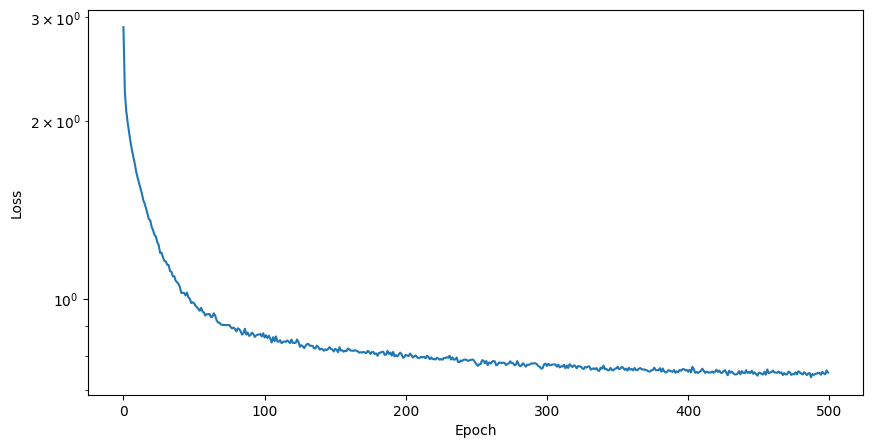

In [54]:
fig, ax = plt.subplots(1, figsize=(10, 5))
ax.plot(losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
plt.show()

Generate some names

In [297]:
# your code here
start_letters = 'abcdefghijklmnopqrstuvwxyzüöä'

for start in start_letters:
  start_token = dset.name_to_indices(start,pad=False)
  name_pred_token = model.generate(start_token,eos_token_idx)
  name_pred = dset.indices_to_name(name_pred_token)
  print(name_pred)

adler
baumgarten
clausen
diehl
ebert
fechner
groth
hamann
itthfer
jacobi
kretschmer
lück
muth
nowak
oswald
pütz
qunderlich
riedl
schweizer
tillmann
ulrich
vetter
weis
xindemann
yilmaz
zimmermann
ürgning
ölsng
äretner


In [165]:
start_letters = 'bbbbbbbbbbbbbbbbbbb'

for start in start_letters:
  start_token = dset.name_to_indices(start,pad=False)
  name_pred_token = model.generate(start_token,eos_token_idx,temperature=1)
  name_pred = dset.indices_to_name(name_pred_token)
  print(name_pred)

bohn
bock
biermann
baumgarten
brückner
baumgart
behnke
bär
baumgärtner
bormann
brehmann
böhme
büchner
bartsch
blank
benz
bayer
bucher
behnke


Plot histograms of the next token distribution for three or so values of T
(choose them in a way so you can see a difference)

In [106]:
# your code here
def plot_sampled_token_histograms(model, tokenizer, input_str, temperatures=[1.0, 0.7, 0.3], num_samples=1000):
    model.eval()
    device = next(model.parameters()).device

    x = dset.name_to_indices(input_str,pad=False)
    x = x.unsqueeze(0)  # Make it (1, seq_len)
    x = x.to(next(model.parameters()).device)
    for T in temperatures:
      logits = model(x)
      last_logits = logits[:, -1, :]  # (1, vocab_size)
      probs = F.softmax(last_logits / T, dim=-1)
      next_token = tc.multinomial(probs, num_samples=num_samples, replacement=True)
      next_token = next_token.squeeze(0).tolist()

      plt.figure(figsize=(8, 3))
      n, bins, patches = plt.hist(next_token, bins=range(len(dset.Alph)), align='left', rwidth=0.9,density=True)

      plt.xticks(ticks=range(len(dset.Alph[:-1])), labels=dset.Alph[:-1])
      plt.title(f"Next Token Distribution (T = {T})")
      plt.xlabel("Token")
      plt.ylabel("Frequency")
      plt.tight_layout()
      plt.show()





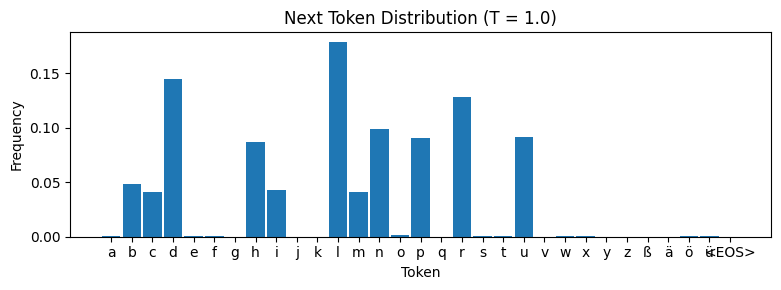

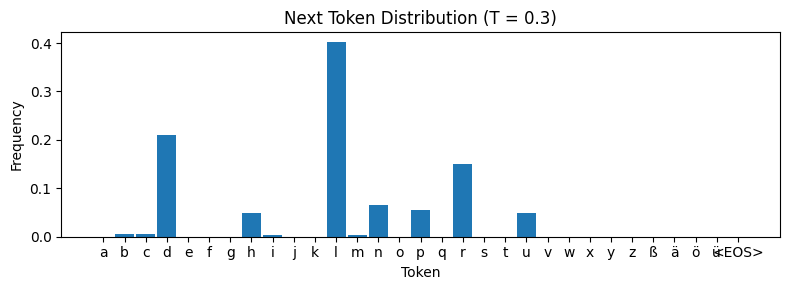

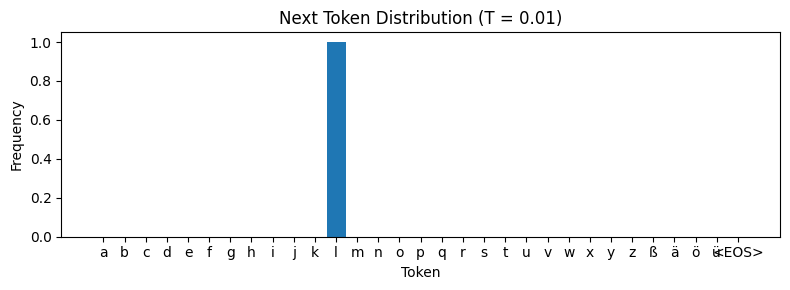

In [108]:
plot_sampled_token_histograms(model, dset,'a', temperatures=[1.0, 0.3, 0.01],num_samples=10000)

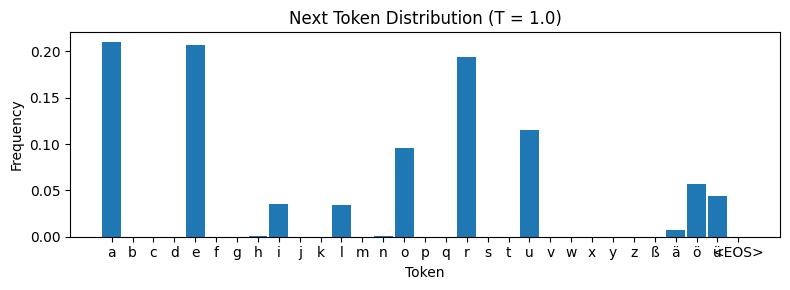

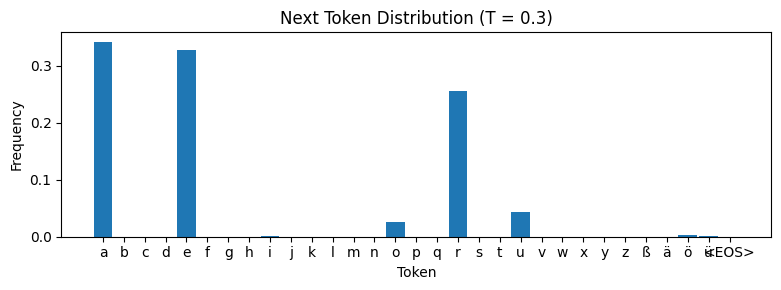

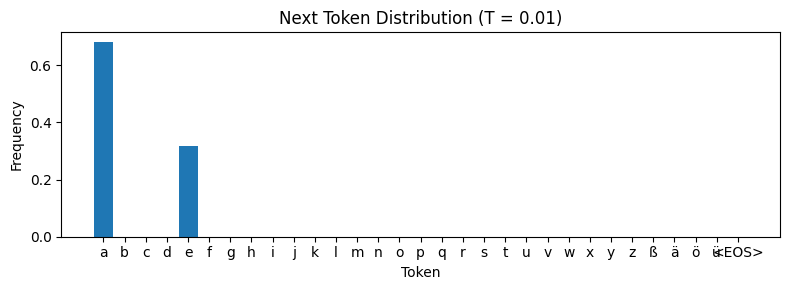

In [112]:
plot_sampled_token_histograms(model, dset,'b', temperatures=[1.0, 0.3, 0.01],num_samples=10000)

We observe that the model has learned something about German last names, if we start with the token 'a' the likelhood for next token being a consonant is larger that a vocal and vice versa when we start with token 'b'. Further more the affect of temperature close to 1 is that the second and third most likely tokens are choosen more than when temperature is lower.